# 🤖 Notebook 3: Autoencoder — Architecture & Training

**Goal:** Build and train a deep Autoencoder exclusively on benign
network traffic. The model learns to compress and reconstruct normal
patterns. Attack traffic will produce high reconstruction error.

In [1]:
import sys
sys.path.append("..")   # lets us import from src/

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os

from src.dataset import get_dataloader
from src.model   import Autoencoder
from src.train   import train_model

# ── Device selection ──────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"✅ Using device: {device}")

✅ Using device: mps


In [2]:
X_train = np.load("../data/processed/X_train.npy")
X_val   = np.load("../data/processed/X_val.npy")
X_test  = np.load("../data/processed/X_test.npy")
y_test  = np.load("../data/processed/y_test.npy")

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}  (0=benign, 1=attack)")

X_train : (33300, 42)
X_val   : (3700, 42)
X_test  : (175341, 42)
y_test  : (175341,)  (0=benign, 1=attack)


In [3]:
BATCH_SIZE = 256

train_loader = get_dataloader(X_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = get_dataloader(X_val,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = get_dataloader(X_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 131
Val batches   : 15
Test batches  : 685


## Model Architecture

In [4]:
INPUT_DIM = X_train.shape[1]  # 42

model = Autoencoder(input_dim=INPUT_DIM).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=42, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=42, bias=True)
  )
)

Total parameters: 4,114


In [5]:
LEARNING_RATE = 1e-3
EPOCHS        = 100
PATIENCE      = 10

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

print(f"Optimizer     : Adam (lr={LEARNING_RATE})")
print(f"Loss          : MSELoss")
print(f"Max epochs    : {EPOCHS}")
print(f"Early stopping: patience = {PATIENCE}")
print(f"Device        : {device}")

Optimizer     : Adam (lr=0.001)
Loss          : MSELoss
Max epochs    : 100
Early stopping: patience = 10
Device        : mps


## Training
> This trains **only on benign traffic**.
> Watch the val_loss converge — that's the model learning "normal."

In [6]:
model, history = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    optimizer    = optimizer,
    criterion    = criterion,
    device       = device,
    epochs       = EPOCHS,
    patience     = PATIENCE
)

 Epoch |   Train Loss |     Val Loss | Status
-------------------------------------------------------
     1 |     0.864624 |     0.615827 | ⭐ best
     5 |     0.206173 |     0.181589 | ⭐ best
    10 |     0.154171 |     0.141850 | ⭐ best
    15 |     0.133666 |     0.127990 | no improve (1/10)
    20 |     0.120285 |     0.109286 | ⭐ best
    25 |     0.108773 |     0.102073 | no improve (1/10)
    30 |     0.100837 |     0.093429 | no improve (1/10)
    35 |     0.095651 |     0.087829 | ⭐ best
    40 |     0.091080 |     0.087085 | no improve (1/10)
    45 |     0.086533 |     0.080696 | ⭐ best
    50 |     0.083754 |     0.077836 | ⭐ best
    55 |     0.081042 |     0.076215 | ⭐ best
    60 |     0.079731 |     0.075169 | ⭐ best
    65 |     0.077729 |     0.078154 | no improve (1/10)
    70 |     0.078234 |     0.073531 | no improve (2/10)
    75 |     0.075435 |     0.071726 | ⭐ best
    80 |     0.075112 |     0.071788 | no improve (1/10)
    85 |     0.072598 |     0.070405 | 

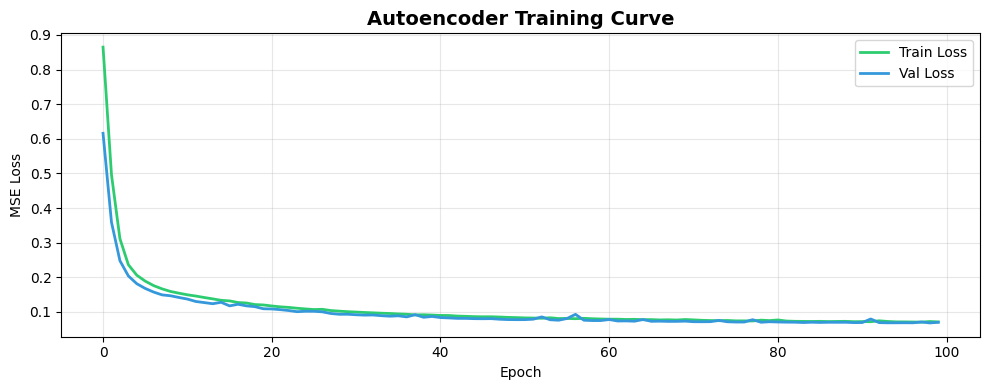

Final Train Loss : 0.071311
Final Val Loss   : 0.070176


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(history["train_loss"], label="Train Loss", color="#2ecc71", linewidth=2)
ax.plot(history["val_loss"],   label="Val Loss",   color="#3498db", linewidth=2)

ax.set_title("Autoencoder Training Curve", fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/03_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Final Train Loss : {history['train_loss'][-1]:.6f}")
print(f"Final Val Loss   : {history['val_loss'][-1]:.6f}")

## Reconstruction Error Distribution

Compute per-sample MSE on the test set.
Benign samples should cluster at **low error**.
Attack samples should cluster at **high error**.
This separation is the core of our detector.

In [8]:
model.eval()
recon_errors = []

with torch.no_grad():
    for batch in test_loader:
        batch  = batch.to(device)
        output = model(batch)
        # Per-sample MSE
        error  = torch.mean((batch - output) ** 2, dim=1)
        recon_errors.extend(error.cpu().numpy())

recon_errors = np.array(recon_errors)

benign_errors = recon_errors[y_test == 0]
attack_errors = recon_errors[y_test == 1]

print(f"Benign errors → mean: {benign_errors.mean():.4f}, "
      f"std: {benign_errors.std():.4f}, "
      f"max: {benign_errors.max():.4f}")
print(f"Attack errors → mean: {attack_errors.mean():.4f}, "
      f"std: {attack_errors.std():.4f}, "
      f"max: {attack_errors.max():.4f}")

Benign errors → mean: 0.2010, std: 2.5871, max: 65.8084
Attack errors → mean: 2.8683, std: 46.2404, max: 6146.2310


/var/folders/f1/q930tc7s57d2_f3xl71241vc0000gn/T/ipykernel_72103/1474116637.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


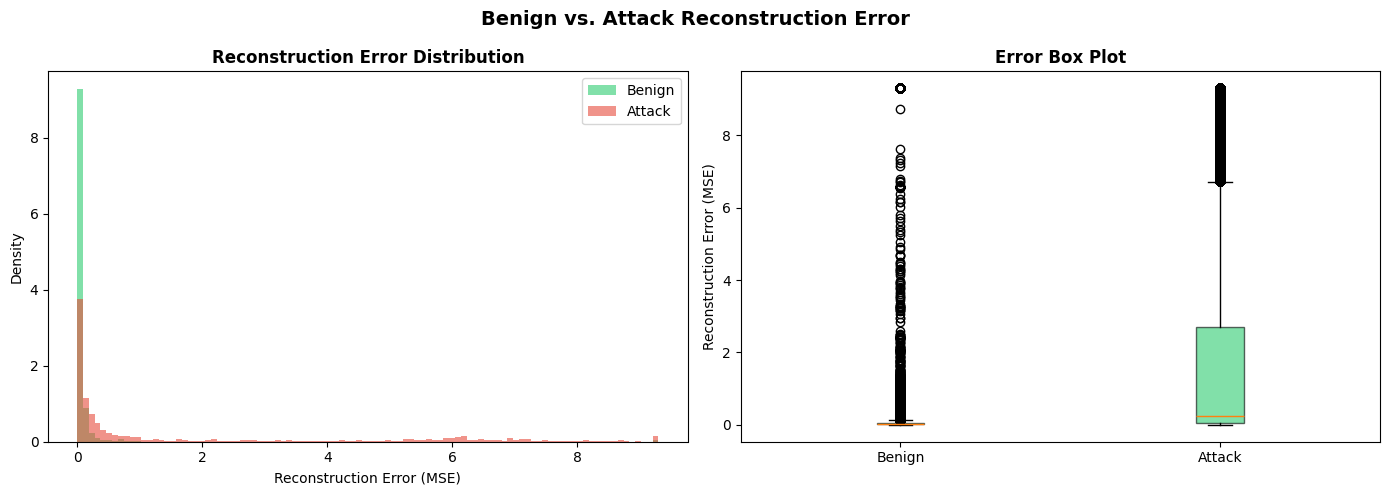

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Overlapping histogram
clip = np.percentile(recon_errors, 99)   # clip extreme outliers for visibility

axes[0].hist(benign_errors.clip(max=clip), bins=100,
             alpha=0.6, color="#2ecc71", label="Benign", density=True)
axes[0].hist(attack_errors.clip(max=clip), bins=100,
             alpha=0.6, color="#e74c3c", label="Attack", density=True)
axes[0].set_title("Reconstruction Error Distribution", fontweight="bold")
axes[0].set_xlabel("Reconstruction Error (MSE)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Plot 2 — Box plot
axes[1].boxplot(
    [benign_errors.clip(max=clip), attack_errors.clip(max=clip)],
    labels=["Benign", "Attack"],
    patch_artist=True,
    boxprops=dict(facecolor="#2ecc71", alpha=0.6),
)
axes[1].set_title("Error Box Plot", fontweight="bold")
axes[1].set_ylabel("Reconstruction Error (MSE)")

plt.suptitle("Benign vs. Attack Reconstruction Error", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/03_reconstruction_error.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
os.makedirs("../outputs/models", exist_ok=True)

torch.save({
    "model_state_dict" : model.state_dict(),
    "input_dim"        : INPUT_DIM,
    "history"          : history,
    "hyperparams"      : {
        "batch_size"    : BATCH_SIZE,
        "learning_rate" : LEARNING_RATE,
        "epochs_trained": len(history["train_loss"]),
    }
}, "../outputs/models/autoencoder.pth")

print("✅ Model saved to outputs/models/autoencoder.pth")

✅ Model saved to outputs/models/autoencoder.pth


In [11]:
print("=" * 55)
print("        AUTOENCODER TRAINING SUMMARY")
print("=" * 55)
print(f"  Architecture   : 42→32→16→8→16→32→42")
print(f"  Parameters     : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device         : {device}")
print(f"  Epochs trained : {len(history['train_loss'])}")
print(f"  Best val loss  : {min(history['val_loss']):.6f}")
print()
print(f"  Benign recon error  (mean) : {benign_errors.mean():.4f}")
print(f"  Attack recon error  (mean) : {attack_errors.mean():.4f}")
print(f"  Separation ratio           : {attack_errors.mean()/benign_errors.mean():.2f}×")
print("=" * 55)

        AUTOENCODER TRAINING SUMMARY
  Architecture   : 42→32→16→8→16→32→42
  Parameters     : 4,114
  Device         : mps
  Epochs trained : 100
  Best val loss  : 0.068369

  Benign recon error  (mean) : 0.2010
  Attack recon error  (mean) : 2.8683
  Separation ratio           : 14.27×
